# Lab 02

> In this lab, you're going to:

1.   Implement Q agent and SARSA agent
2.   Study about on-policy, off-policy and how they trade-off convergence speed for sample-efficiency
3.   Create simple plot to visualize your agent's results

> **NOTICE 1**: This lab calls to the ***MABe_agent*** class of previous lab. **IF** you have not finish the previous lab, you should not be aable to complete this lab

> **NOTICE 2**: Convert your previous lab's solution or instructor's solution to format **.py** then place that file in this file's directory. We're going to inherit some classes.

> **NOTICE 3**: This lab's solution **will not** be given due to the inheritance of the given lab 01's solution. You can easily implement Q-learning and SARSA by changing the estimation fomula.





Also this lab, we're going to reuse last week's environment: **GridWorld**. The different is our agent. If you don't remember what is GridWorld, please revise your last lab excercise in advance

In [1]:
# from Lab01_problem import environment, MABe_agent

Estimation updates:
>Q-learning:
$Q(S_t,A_t) = (1-\alpha)Q(S_t,A_t) + \alpha(R + \gamma max_a Q(S_{t+1},a))$

>SARSA:
$Q(S_t, A_t) = (1-\alpha)Q(S_t,A_t) + \alpha(R + \gamma Q(S_{t+1},A_{t+1}))$



---
On-policy and Off-policy
---
1. On-policy:
  
  **On-policy** is a group of reinforcement learning methods that **use the value resulting from a different policy to update the current policy**

2. Off-policy:

  **Off-policy** is a group of reinforcement learning methods that **use the value resulting directly from the current policy to update itself**

3. On-policy, off-policy, cons & pros:

*   Off-policy methods are usually learning more about the environment they can use multiple policies' experience. Thus, they're more data-sampling efficient. Famous: *Q-learning, DQN and its extensions*

*   On-policy methods are usually more realistic (most of the time, we can only depend on our own policy for the data we can collect, especially in policy-based methods) and fast converging but not as sampling-efficient as off-policy methods




## Q-learning method

In this section, we're going to implement tabular Q-learning agent and see its performance.

Q-agent inherits from MABe-agent we implemented earlier in this course

In [2]:
from collections import defaultdict
import numpy as np

In [3]:
class environment:
  def __init__(self, grid_height, grid_width):
    """
    The map is initialized with height and width are varible of your choice
    start: List of location where you step in, you get to the corresponding location in list 'end'
           For example:
              if you step in location start[3] then you get to new location end[3] then obtain the reward value of reward[3]
    reward: List of reward value where you move from a location in 'start' list to the corresponding location in 'end' list
    """
    self.height = grid_height
    self.width = grid_width
    self.start = []
    self.end = []
    self.reward = []
    self.map = np.array([i for i in range(grid_height * grid_width)])
    self.action_space = [0,1,2,3]

  def get_Map(self):
    print(self.map.reshape([self.width, self.height]))

  def get_NumState(self):
    return self.height * self.width

  def map_Designate(self, start_cell, end_cell, reward):
    self.start.append(start_cell)
    self.end.append(end_cell)
    self.reward.append(reward)

  def get_Observation(self, location, action):
    # If the agent observe the environment the first time
    if action == -1:
      return None, self.action_space, None

    new_location = 0
    # If the agent at special locations, all action lead to a single location, gain reward
    if location in self.start:
      idx = self.start.index(location)
      new_location = self.end[idx]
      reward = self.reward[idx]
      return new_location, self.action_space, reward

    # If the agent not at special locations, reward = 0
    reward = 0
    # Action: UP: 0, DOWN: 1, LEFT: 2, RIGHT: 3
    # Actions that get the agent out of the map, result in no change at all
    if action == 0: #UP
      if location - self.width < 0:
        new_location = location
      else:
        new_location = location - self.width

    elif action == 1: #DOWN
      if location + self.width > self.height * self.width - 1:
        new_location = location
      else:
        new_location = location + self.width

    elif action == 2: #LEFT
      if location % self.width == 0:
        new_location = location
      else:
        new_location = location - 1

    elif action == 3: #RIGHT
      if (location + 1) % self.width == 0:
        new_location = location
      else:
        new_location = location + 1

    return new_location, self.action_space, reward

In [4]:
class MAB_agent:
  def __init__(self, envir, init_location):
    # Initialize the agent with the environment and starting location
    self.envir = envir
    # Trace the reward
    self.reward_trace = []
    # initialize the first location
    self.location_now = init_location
    # TODO: implement other features to the agent so it can perform MAB algorithm
    # Initialize variables to store the last action and state
    self.lastAction = None
    self.lastState = None
    # Initialize a dictionary to store the value of each state-action pair
    self.value_table = {}


  def get_TotalReward(self):
    # Calculate the total reward obtained by the agent
    return np.sum(self.reward_trace)

  # Running in Simulator
  def getAction(self, observation):
    # Get the current location, action space, and previous reward from the observation
    location_now, action_space, pre_reward = observation
    # NOTICE: the first observation is (None, [0,1,2,3], None)
    # You should process the 'None' value
    if location_now is not None:
      self.location_now = location_now

    if pre_reward is not None:
      # Append the previous reward to the reward trace
      self.reward_trace.append(pre_reward)

    # Choose a random action from the action space with equal probability
    action = np.random.choice(action_space, p=[1/(len(action_space)) for action in action_space])


    # Assert valid action
    assert action in action_space, "INVALID action taken"
    return action

In [5]:
class MABe_agent(MAB_agent):
  def __init__(self, envir, init_location, epsilon, alpha=None):
    super().__init__(envir, init_location)
    self.epsilon = epsilon
    self.alpha = alpha
    self.Q = {}
    self.N = {}
    self.lastAction = None

  def _ensure_actions(self, action_space):
    for a in action_space:
        self.Q.setdefault(a, 0.0)
        self.N.setdefault(a, 0)

  # Override
  def getAction(self, observation):
    location_now, action_space, pre_reward = observation
    # NOTICE: the first observation is (NONE, [0,1,2,3], None)
    # You should process the 'None' value
    if location_now is not None:
      self.location_now = location_now

    if pre_reward is not None and self.lastAction is not None:
      self.reward_trace.append(pre_reward)
      a = self.lastAction
      self.N[a] += 1
      if self.alpha is None:
        # trung bình mẫu
        self.Q[a] += (pre_reward - self.Q[a]) / self.N[a]
      else:
        # cập nhật gia quyền
        self.Q[a] += self.alpha * (pre_reward - self.Q[a])
    # đảm bảo đã khởi tạo Q, N cho các action
    self._ensure_actions(action_space)

    # epsilon-greedy
    if np.random.rand() < self.epsilon:
      action = np.random.choice(action_space)
    else:
      # khai thác
      maxQ = max(self.Q[a] for a in action_space)
      best = [a for a in action_space if self.Q[a] == maxQ]
      action = np.random.choice(best)

    self.lastAction = action

    assert action in action_space, "INVALID action taken"
    return action

In [6]:
# Implement your agent
class Q_agent(MABe_agent):
  def __init__(self, envir, init_location, epsilon, alpha=0.1, gamma=0.99):
    super().__init__(envir, init_location, epsilon, alpha=alpha)
    self.gamma = gamma
    # Q_table[s][a] -> float
    self.Q_table = defaultdict(lambda: defaultdict(float))
    # dùng lại lastState/lastAction của lớp cha

  def _ensure_state_actions(self, state, action_space):
    # khởi tạo Q(s,a)=0 cho mọi a trong action_space của state hiện tại
    if state is None:
      return
    for a in action_space:
      _ = self.Q_table[state][a]   # kích hoạt defaultdict

  # Override
  def getAction(self, observation):
    state, action_space, reward = observation

    # nhận thưởng cho (lastState, lastAction) từ bước trước và cập nhật theo Q-learning
    if reward is not None:
      self.reward_trace.append(reward)

    if (reward is not None) and (self.lastState is not None) and (self.lastAction is not None):
      # đảm bảo đã có Q(s', ·)
      self._ensure_state_actions(state, action_space)
      # max_a' Q(s',a')
      max_next = 0.0 if state is None or len(action_space) == 0 \
                 else max(self.Q_table[state][a] for a in action_space)
      s, a = self.lastState, self.lastAction
      td_target = reward + self.gamma * max_next
      td_error  = td_target - self.Q_table[s][a]
      self.Q_table[s][a] += self.alpha * td_error

    # cập nhật state hiện tại
    if state is not None:
      self.location_now = state
    self._ensure_state_actions(state, action_space)

    # chọn hành động theo epsilon-greedy trên Q_table[state]
    if (state is None) or (np.random.rand() < self.epsilon):
      action = np.random.choice(action_space)                 # explore
    else:
      qvals = [self.Q_table[state][a] for a in action_space]  # exploit
      maxQ = np.max(qvals)
      best = [a for a in action_space if self.Q_table[state][a] == maxQ]
      action = np.random.choice(best)

    # lưu để cập nhật ở bước sau
    self.lastState  = state
    self.lastAction = action

    assert action in action_space, "INVALID action taken"
    return action

In [7]:
# Create environment
Envir = environment(8,8)
Envir.get_Map()
Envir.map_Designate(17,56,-15)
Envir.map_Designate(18,56,-15)
Envir.map_Designate(19,56,-15)
Envir.map_Designate(21,56,-15)
Envir.map_Designate(25,56,-15)
Envir.map_Designate(33,56,-15)
Envir.map_Designate(41,56,-15)
Envir.map_Designate(42,56,-15)
Envir.map_Designate(43,56,-15)
Envir.map_Designate(46,56,-15)
Envir.map_Designate(47,56,-15)
Envir.map_Designate(47,56,-15)
Envir.map_Designate(15,56,+15)
Envir.map_Designate(1,10,+5)
Envir.map_Designate(26,56,+20)

[[ 0  1  2  3  4  5  6  7]
 [ 8  9 10 11 12 13 14 15]
 [16 17 18 19 20 21 22 23]
 [24 25 26 27 28 29 30 31]
 [32 33 34 35 36 37 38 39]
 [40 41 42 43 44 45 46 47]
 [48 49 50 51 52 53 54 55]
 [56 57 58 59 60 61 62 63]]


In [8]:
init_location = 0
epsilon = 1e-4
dummy_q_agent = Q_agent(envir=Envir, init_location=init_location, epsilon=epsilon)

num_iter = 1000
log_freq = 100
Data_plot1 = []

for i in range(num_iter):
    if i == 0:
        # đúng giao thức lần đầu
        env_observation = Envir.get_Observation(location=init_location, action=-1)
    else:
        # đảm bảo location_now là int
        assert isinstance(dummy_q_agent.location_now, (int, np.integer)), \
            f"type(location_now)={type(dummy_q_agent.location_now)}"
        env_observation = Envir.get_Observation(
            location=dummy_q_agent.location_now, action=chosen_action
        )

    chosen_action = dummy_q_agent.getAction(observation=env_observation)

    if (i + 1) % log_freq == 0:
        aver = np.mean(dummy_q_agent.reward_trace) if dummy_q_agent.reward_trace else 0.0
        Data_plot1.append(aver)
        print('iter:', i + 1, '\tTotal reward:', dummy_q_agent.get_TotalReward(), '\tAverage:', aver)


iter: 100 	Total reward: -105 	Average: -1.0606060606060606
iter: 200 	Total reward: -165 	Average: -0.8291457286432161
iter: 300 	Total reward: -210 	Average: -0.7023411371237458
iter: 400 	Total reward: -285 	Average: -0.7142857142857143
iter: 500 	Total reward: -345 	Average: -0.6913827655310621
iter: 600 	Total reward: -395 	Average: -0.659432387312187
iter: 700 	Total reward: -455 	Average: -0.6509298998569385
iter: 800 	Total reward: -500 	Average: -0.6257822277847309
iter: 900 	Total reward: -530 	Average: -0.5895439377085651
iter: 1000 	Total reward: -545 	Average: -0.5455455455455456


## SARSA

SARSA is the on-policy version of Q-learning
The different is observable through its updating rule

> $Q(S_t, A_t) = (1-\alpha)Q(S_t,A_t) + \alpha(R + \gamma Q(S_{t+1},A_{t+1}))$

Meaning: the sequence of observation is
> $S_t \to A_t \to R \to S_{t+1} \to A_{t+1}$

*HENCE*: **S-A-R-S-A**


In [9]:
import numpy as np

# Implement your agent
class SARSA_agent(MABe_agent):
  def __init__(self, envir, init_location, epsilon, alpha=0.1, gamma=0.99):
    # giữ epsilon từ MABe_agent, không dùng alpha của MABe (để None)
    super().__init__(envir, init_location, epsilon, alpha=None)
    self.alpha = alpha
    self.gamma = gamma

    # Q_table: Q[s] = np.array([Q(s,a0), Q(s,a1), ...]) theo thứ tự action_space
    self.Q_table = {}

    # lưu vết cho cập nhật TD
    self.lastState = None
    self.lastAction = None
    self.lastActionSpace = None  # rất quan trọng nếu action_space thay đổi theo state

  # --- helpers ---
  def _ensure_state(self, state, action_space):
    """Khởi tạo Q[state] theo kích thước action_space hiện tại (nếu chưa có hoặc kích thước đổi)."""
    if state is None:
      return
    if (state not in self.Q_table) or (len(self.Q_table[state]) != len(action_space)):
      self.Q_table[state] = np.zeros(len(action_space), dtype=float)

  def _epsilon_greedy(self, state, action_space):
    """Chọn action theo ε-greedy từ Q_table[state]."""
    self._ensure_state(state, action_space)
    if np.random.rand() < self.epsilon:
      return np.random.choice(action_space)  # explore
    # exploit
    qs = self.Q_table[state]
    maxQ = np.max(qs)
    best_idx = np.flatnonzero(qs == maxQ)
    idx = np.random.choice(best_idx)
    return action_space[idx]

  def _get_q(self, state, action, action_space):
    """Lấy Q(state, action) theo thứ tự action_space."""
    self._ensure_state(state, action_space)
    idx = action_space.index(action)
    return self.Q_table[state][idx]

  def _set_q(self, state, action, action_space, value):
    """Gán Q(state, action) theo thứ tự action_space."""
    self._ensure_state(state, action_space)
    idx = action_space.index(action)
    self.Q_table[state][idx] = value

  # --- core ---
  def getAction(self, observation):
    """
    observation = (location_now, action_space, pre_reward)
    - Ở bước t: env trả về (s_{t}, A(s_t), r_{t-1})
    - Ta phải chọn a_t theo ε-greedy tại s_t, rồi dùng SARSA để cập nhật Q(s_{t-1}, a_{t-1})
    """
    location_now, action_space, pre_reward = observation

    if location_now is not None:
      self.location_now = location_now

    # Chọn a' ở s' (on-policy) trước để dùng trong target
    # (nếu terminal mà action_space trống thì không chọn, nhưng thường action_space != [])
    self._ensure_state(location_now, action_space)
    a_prime = self._epsilon_greedy(location_now, action_space)

    # Nếu đã có (s_{t-1}, a_{t-1}) và r_{t-1} thì cập nhật SARSA
    if (pre_reward is not None) and (self.lastState is not None) and (self.lastAction is not None):
      self.reward_trace.append(pre_reward)

      # Q(s_{t-1}, a_{t-1})
      q_old = self._get_q(self.lastState, self.lastAction, self.lastActionSpace)

      # target = r_{t-1} + gamma * Q(s_t, a_t) (với a_t = a_prime)
      next_q = self._get_q(location_now, a_prime, action_space)
      td_target = pre_reward + self.gamma * next_q

      # cập nhật
      q_new = q_old + self.alpha * (td_target - q_old)
      self._set_q(self.lastState, self.lastAction, self.lastActionSpace, q_new)

    # cập nhật vết cho bước sau
    self.lastState = location_now
    self.lastAction = a_prime
    self.lastActionSpace = list(action_space)  # copy để cố định mapping chỉ số

    # trả về a_t để env thực thi
    assert a_prime in action_space, "INVALID action taken"
    return a_prime


In [10]:
init_location=0
epsilon = 1e-2
dummy_sarsa_agent = SARSA_agent(envir=Envir, init_location=init_location, epsilon = epsilon)
num_iter = 1000

log_freq = 100
Data_plot2 = []

for i in range(num_iter):
  env_observation = (init_location, Envir.action_space, None)
  if i > 0:
    env_observation = Envir.get_Observation(location=dummy_sarsa_agent.location_now, action=chosen_action)

  chosen_action = dummy_sarsa_agent.getAction(observation=env_observation)
  if (i + 1) % log_freq == 0:
    aver = np.mean(dummy_sarsa_agent.reward_trace)
    Data_plot2.append(aver)
    print('iter: ' + str(i + 1) + '\t Total reward: ' + str(dummy_sarsa_agent.get_TotalReward()) + '\t Average: ' + str(aver))


iter: 100	 Total reward: -100	 Average: -1.0101010101010102
iter: 200	 Total reward: -205	 Average: -1.0301507537688441
iter: 300	 Total reward: -280	 Average: -0.9364548494983278
iter: 400	 Total reward: -295	 Average: -0.7393483709273183
iter: 500	 Total reward: -325	 Average: -0.6513026052104208
iter: 600	 Total reward: -355	 Average: -0.5926544240400667
iter: 700	 Total reward: -400	 Average: -0.5722460658082976
iter: 800	 Total reward: -445	 Average: -0.5569461827284106
iter: 900	 Total reward: -475	 Average: -0.5283648498331479
iter: 1000	 Total reward: -490	 Average: -0.4904904904904905


## Plot your results

Compare Q-learning's and SARSA's performance

In [11]:
import matplotlib.pyplot as plt

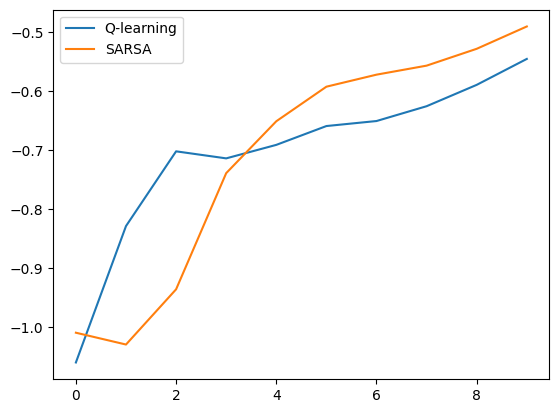

In [12]:
# TODO: visualize your agent's performance
fig = plt.figure()
plt.plot(Data_plot1, label="Q-learning")
plt.plot(Data_plot2, label="SARSA")
plt.legend()
plt.show()